# Изучение рынка заведений общественного питания Москвы

- Автор: Андриянова Анастасия
- Дата: 08.10.25

### Цели и задачи проекта

- Цель: Провести комплексное исследование рынка общественного питания Москвы для определения оптимальных параметров открытия нового заведения, которое будет максимально соответствовать рыночным трендам и предпочтениям потребителей.
- Задачи:
1. Изучить структуру рынка по категориям заведений.
2. Проанализировать географическое распределение заведений по районам Москвы.
3. Исследовать соотношение сетевых и несетевых заведений.
4. Определить типичную вместимость (количество мест) для разных категорий.
5. Проанализировать рейтинги заведений и факторы, влияющие на них.
6. Изучить ценовую политику и средние чеки в разных районах.
7. Выявить популярные сети и их особенности.
8. Проанализировать режим работы заведений (круглосуточные и другие).

### Описание данных

#### Основные данные о заведениях (rest_info.csv):
name — название заведения

address — адрес заведения

district — административный район (например, Центральный административный округ)

category — категория заведения (кафе, пиццерия, кофейня и др.)

hours — информация о днях и часах работы

rating — рейтинг заведения по оценкам пользователей Яндекс Карт (шкала от 0 до 5.0)

chain — признак сетевого заведения:

0 — не сетевое

1 — сетевое

seats — количество посадочных мест

#### Данные о ценах (rest_price.csv):
price — категория цен (средние, ниже среднего, выше среднего и т.д.)

avg_bill — строковое описание средней стоимости заказа (диапазоны цен)

middle_avg_bill — числовая оценка среднего чека (только для записей, начинающихся с "Средний счёт")

middle_coffee_cup — числовая оценка стоимости чашки капучино (только для записей, начинающихся с "Цена одной чашки капучино")

### Содержимое проекта

1. Загрузка и предобработка данных
2. Анализ структуры рынка
3. Анализ сетевых заведений
4. Анализ вместимости заведений
5. Анализ рейтингов и качества
6. Ценовой анализ
7. Анализ режима работы
8. Итоговые выводы и рекомендации

## 1. Загрузка данных и знакомство с ними


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install phik

In [2]:
from phik import phik_matrix

In [3]:
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

- Познакомимся с данными и изучим общую информацию о них.

In [4]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [5]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [6]:
rest_info.isnull().sum()

id             0
name           0
category       0
address        0
district       0
hours        536
rating         0
chain          0
seats       3611
dtype: int64

In [7]:
rest_info['hours'].isnull().sum()/len(rest_info)

0.06376397811087318

In [8]:
rest_info['seats'].isnull().sum()/len(rest_info)

0.4295741137282893

Датасет rest_info содержит информацию о заведениях общественного питания Москвы и включает 8 406 записей с 9 характеристиками для каждого заведения. 
- Названия столбцов соответствуют стандарту snake_case
- Обнаружены пропуски в столбцах hours (536 пропусков) и seats (3611 пропусков)
- Столбец chain содержит бинарные значения (0/1) — можно оптимизировать размерность
- Столбец seats хранит целочисленные значения в формате float64 — требует преобразования
- Все основные характеристики заведений заполнены полностью (id, name, category, address, district, rating)

In [9]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [10]:
rest_price.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


In [11]:
rest_price.isnull().sum()

id                      0
price                 743
avg_bill              242
middle_avg_bill       909
middle_coffee_cup    3523
dtype: int64

In [12]:
rest_price['price'].isnull().sum()/len(rest_price)

0.1830951207491375

In [13]:
rest_price['avg_bill'].isnull().sum()/len(rest_price)

0.05963528831936915

Датасет rest_price содержит информацию о ценах в заведениях общественного питания Москвы и включает 4 058 записей с 5 характеристиками.
- Значительное количество пропусков почти во всех слобцах, для middle_avg_bill и  middle_coffee_cup это нормально, поскольку столбцы являются категориями столбца avg_bill. 
- Столбец avg_bill содержит разнородные данные о ценах в текстовом формате 
- Столбец middle_avg_bill и  middle_coffee_cup имеют тип float64, можно оптимизировать
- Столбец middle_coffee_cup заполнен только для 535 записей 

In [14]:
#rest_price['price'].unique()

---

### Промежуточный вывод



Объём данных: 8406 заведений, 4058 записей о ценах. Количество мест как дробное число вместо целого. Есть неоптимальные форматы данных в chain, seats, middle_avg_bill, middle_coffee_cup 

### Подготовка единого датафрейма

- Объединим данные двух датасетов в один

In [15]:
df = rest_info.merge(rest_price, how = 'left', on = 'id')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


Дабы не потерять почти половину данных о заведениях, объединение производилось с помощью left join

## 2. Предобработка данных

Подготовим данные к исследовательскому анализу: в пункте 1.1 мы ознакомились с типами данных, теперь перейдем к их преобразованию. 

In [17]:
df.isna().sum() / df.shape[0]
# доля пропуксов в каждом стобце

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

Гипотезы появления пропусков:
- seats (43%) - данные о вместимости часто не публикуются онлайн
- Ценовые данные (55-94%) - многие заведения не указывают цены в открытых источниках
- hours (6%) - редкие случаи отсутствия информации о режиме работы
- middle_coffee_cup (94%) - заполнены только для кофеен и баров

In [18]:
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [19]:
# hours - небольшой процент пропусков, заполняем
df['hours'] = df['hours'].fillna('режим работы не указан')

In [20]:
# данные о вместимости часто не публикуются онлайн, запомлним их исходя из локации и категории
#cat_dist_median = df.groupby(['category', 'district'])['seats'].transform('mean')

In [21]:
#df['seats'] = df['seats'].fillna(cat_dist_median)

In [22]:
#и оптимизируем типы
#df['seats'] = df['seats'].astype('int16')


In [23]:
#опитимизируем тип данных, шде хранится 0 и 1
df['chain'] = df['chain'].astype('int8')

In [24]:
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float64
chain                   int8
seats                float64
price                 object
avg_bill              object
middle_avg_bill      float64
middle_coffee_cup    float64
dtype: object

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [25]:
df['price'] = df['price'].fillna('не указано')
df['avg_bill'] = df['avg_bill'].fillna('не указано')

In [26]:
has_avg_bill_no_middle = df[(df['avg_bill'].notna()) & (df['middle_avg_bill'].isna())]
print(f"Записей с avg_bill но без middle_avg_bill: {len(has_avg_bill_no_middle)}")
# анализируем содержание таких записей
if len(has_avg_bill_no_middle) > 0:
    # примеры avg_bill без middle_avg_bill:
    print(has_avg_bill_no_middle['avg_bill'].unique()[:10])

Записей с avg_bill но без middle_avg_bill: 5257
['не указано' 'Цена чашки капучино:155–185 ₽' 'Цена бокала пива:250–350 ₽'
 'Цена бокала пива:120–350 ₽' 'Цена чашки капучино:150–190 ₽'
 'Цена чашки капучино:120–170 ₽' 'Цена чашки капучино:100–200 ₽'
 'Цена бокала пива:90–230 ₽' 'Цена чашки капучино:150–210 ₽'
 'Цена чашки капучино:80–160 ₽']


Обоснование: Заполнение этих пропусков привело бы к искажению данных, так как пропуски означают отсутствие соответствующей информации, а не ошибку в данных. Заполнены только записи, где avg_bill начинается с "Средний счёт". Аналогичная ситуация и с middle_coffee_cup, где данные только о кофе

In [27]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,не указано,не указано,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [28]:
# проверка на явные дубликаты
df.duplicated().sum()

0

In [29]:
df['name'].duplicated().sum()

2792

In [30]:
# проверим неявные дубликаты по id
df.duplicated(subset='id').sum()

0

In [31]:
# преобразуем названия и адреса к одному виду
df['name'] = df['name'].str.lower().str.strip()
df['district'] = df['district'].str.lower().str.strip()

In [32]:
# приведем адреса к одному виду
def normalize_address(address):
    address = address.lower()
    replacements = {
        'ул.': 'улица',
        'пр.': 'проспект',
        'пер.': 'переулок',
        'наб.': 'набережная',
        'ш.': 'шоссе',
        'б-р': 'бульвар',
        'пр-т': 'проспект',
        'м.': 'метро',
        'д.': 'дом',
        'корп.': 'корпус',
        'стр.': 'строение',
        'к.': 'корпус'
    }
    for short, full in replacements.items():
        address = address.replace(short, full)
    address = ' '.join(address.split())
    return address
df['address'] = df['address'].apply(normalize_address)

In [33]:
df.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,не указано,не указано,NaN,NaN
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корпус 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [34]:
# cохраняем информацию о количестве дубликатов перед удалением
duplicates_before = df.duplicated(subset=['name', 'category', 'address'], keep=False).sum()
print(f"Дубликатов перед удалением: {duplicates_before}")
print(f"Записей перед удалением: {len(df)}")
# eдаляем дубликаты, оставляя первое вхождение
df = df.drop_duplicates(subset=['name', 'category', 'address'], keep='first')
print(f"Осталось записей: {len(df)}")


Дубликатов перед удалением: 4
Записей перед удалением: 8406
Осталось записей: 8404


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [35]:
def check_24_7(hours_str):
    hours_lower = hours_str.lower()
    hours_lower = hours_str.strip()
    round_the_clock_indicators = [
        'ежедневно, круглосуточно',
        'ежедневно,круглосуточно'
    ]
    
    for indicator in round_the_clock_indicators:
        if indicator in hours_lower:
            return True
        return False
    
df['is_24_7'] = df['hours'].apply(check_24_7)

In [36]:
df.head(15)

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup,is_24_7
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,wowфли,кафе,"москва, улица дыбенко, 7/1",северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,не указано,не указано,NaN,NaN,False
1,045780ada3474c57a2112e505d74b633,четыре комнаты,ресторан,"москва, улица дыбенко, 36, корпус 1",северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN,False
2,1070b6b59144425896c65889347fcff6,хазри,кафе,"москва, клязьминская улица, 15",северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN,False
3,03ac7cd772104f65b58b349dc59f03ee,dormouse coffee shop,кофейня,"москва, улица маршала федоренко, 12",северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,не указано,Цена чашки капучино:155–185 ₽,NaN,170.0,False
4,a163aada139c4c7f87b0b1c0b466a50f,иль марко,пиццерия,"москва, правобережная улица, 1б",северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN,False
5,8a343546b24e4a499ad96eb7d0797a8a,sergio pizza,пиццерия,"москва, ижорская улица, вл8б",северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN,средние,не указано,NaN,NaN,False
6,96ebceb1a09e4e3191133b9fe0379a64,огни города,"бар,паб","москва, клязьминская улица, 9, строение 3",северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0,средние,Средний счёт:199 ₽,199.0,NaN,False
7,0243288b78024af090b8e947842c969c,mr. уголёк,быстрое питание,"москва, клязьминская улица, 9, строение 3",северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0,средние,Средний счёт:200–300 ₽,250.0,NaN,False
8,36aeb0ffa69c48fdb0021549520deb10,donna maria,ресторан,"москва, дмитровское шоссе, 107, корпус 4",северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0,средние,Средний счёт:от 500 ₽,500.0,NaN,False
9,487167877eb04288bc90d4fa80646fc2,готика,кафе,"москва, ангарская улица, 39",северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0,средние,Средний счёт:1000–1200 ₽,1100.0,NaN,False


In [37]:
initial_count = 8406  # исходное количество после объединения
final_count = len(df)
duplicates_removed = initial_count - final_count

print(f"1. ДУБЛИКАТЫ:")
print(f"   Исходно: {initial_count} записей")
print(f"   После удаления дубликатов: {final_count} записей")
print(f"   Удалено: {duplicates_removed} записей")

1. ДУБЛИКАТЫ:
   Исходно: 8406 записей
   После удаления дубликатов: 8404 записей
   Удалено: 2 записей


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.

 Обработка пропусков:

- hours (6%): заполнены значением "режим работы не указан"
- price и avg_bill: пропуски заменены на "не указано", поля типа object
- middle_avg_bill и middle_coffee_cup не менялись, ибо пропуски намеренные и имеют распределение по категории
- seats (43%): заполнены медианными значениями по комбинации категория-район
- новый столбец is_24_7 имеет индикатор true|falsе - круглосуточность заведения

- столбцы name, category, adress, district, hours приведены к единому стилю во избежание дубликатов
- удалены 2 дубликата по комбинации name+category+address

- ДУБЛИКАТЫ:
   Исходно: 8406 записей
   После удаления дубликатов: 8404 записей
   Удалено: 2 записей (0.0%)

## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

In [38]:
category_stats = df['category'].value_counts()

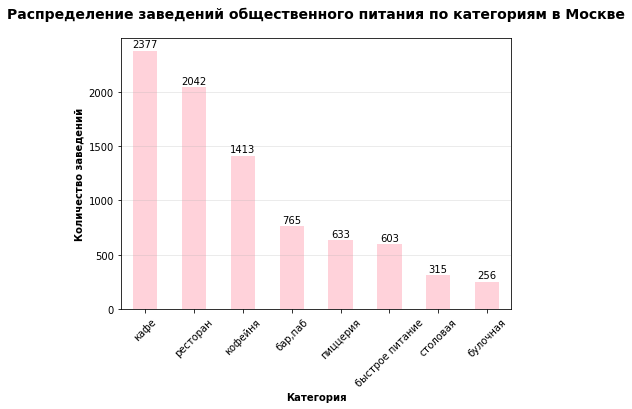

In [39]:

ax = df['category'].value_counts().plot(kind='bar', 
               rot=0, 
               legend=False,
               figsize = (7,5),
               color='pink',
               alpha=0.7
)
for i, v in enumerate(df['category'].value_counts()):
    ax.text(i, v + 10, str(v), 
            ha='center', va='bottom', 
            fontsize=10)
plt.title('Распределение заведений общественного питания по категориям в Москве', fontsize=14, fontweight='bold', pad=20) 
plt.xlabel('Категория', fontweight='bold')
plt.ylabel('Количество заведений', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()

Вывод по графику:

Явные лидеры: Кафе, рестораны и кофейни занимают более 50% рынка

Сильная концентрация: Топ-3 категории = 60% всех заведений

Рекомендация: Для нового проекта стоит рассматривать популярные категории, но оценить конкуренцию в топ-сегменте

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

In [40]:
df['district'].value_counts()

центральный административный округ         2242
северный административный округ             898
южный административный округ                892
северо-восточный административный округ     891
западный административный округ             851
восточный административный округ            798
юго-восточный административный округ        714
юго-западный административный округ         709
северо-западный административный округ      409
Name: district, dtype: int64

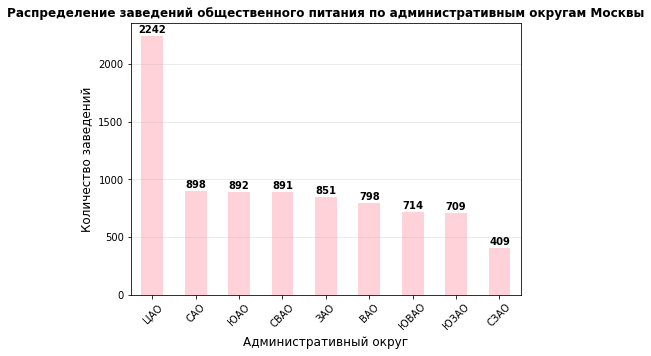

In [41]:
district_abbr = {
    'центральный административный округ': 'ЦАО',
    'северный административный округ': 'САО', 
    'южный административный округ': 'ЮАО',
    'северо-восточный административный округ': 'СВАО',
    'западный административный округ': 'ЗАО',
    'восточный административный округ': 'ВАО',
    'юго-восточный административный округ': 'ЮВАО',
    'юго-западный административный округ': 'ЮЗАО',
    'северо-западный административный округ': 'СЗАО'
}

district_counts_abbr = df['district'].value_counts().rename(index=district_abbr)
plt.figure(figsize=(7, 5))
ax = district_counts_abbr.plot(kind = 'bar',color='pink', alpha=0.7,rot = 0.5)
plt.title('Распределение заведений общественного питания по административным округам Москвы', 
          fontsize=12, fontweight='bold')
plt.xlabel('Административный округ', fontsize=12)
plt.ylabel('Количество заведений', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


for bar in ax.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()


Можно заметить, что в ЦАО сконцентрировано абсолютное большинство заведений - 2242, во всех остальных районах Москвы, кроме СЗАО примерно одинаковое кол-во заведений ~800, в СЗАО всего лишь 409 точек общественного питания. Сердце столицы предоставляет высокие цены на аренду и огромную конкуренцию в самом туристическом округе.

In [42]:
cao_data = df[df['district'] == 'центральный административный округ']
cao_category_stats = cao_data['category'].value_counts()
cao_category_stats

ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64

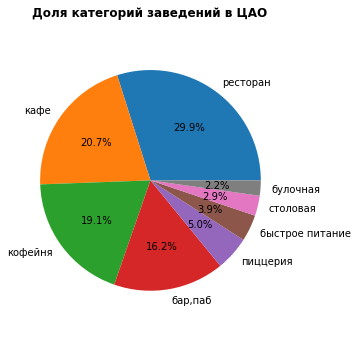

In [43]:
plt.figure(figsize=(5, 5))
plt.pie(cao_category_stats.values, labels=cao_category_stats.index, autopct='%1.1f%%')
plt.title('Доля категорий заведений в ЦАО', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

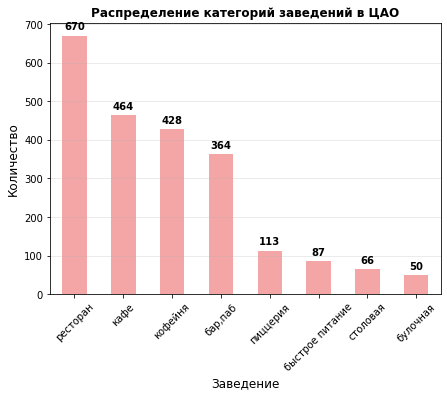

In [44]:
plt.figure(figsize=(7, 5))
ax = cao_data.groupby('category')['category'].count().sort_values(ascending=False).plot(
    kind='bar', color='lightcoral', alpha=0.7, rot=0)

plt.title('Распределение категорий заведений в ЦАО', 
          fontsize=12, fontweight='bold')
plt.xlabel('Заведение', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


for bar in ax.patches:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'{int(height)}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.show()


В ЦАО наибольший процент заведений (29.9%) - рестораны, кафе и кофеен на 10% меньше, наименее популярны столовые и булочные. (Центр Москвы располагает к более культурным, пафосным и высококачественным заведениям)

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

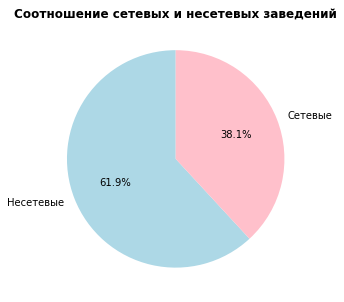

In [45]:
plt.figure(figsize=(5, 5))
df['chain'].value_counts().plot(kind='pie', labels=['Несетевые', 'Сетевые'], autopct='%1.1f%%', 
        colors=['lightblue', 'pink'], startangle=90)
plt.title('Соотношение сетевых и несетевых заведений', fontsize=12, fontweight='bold')
plt.ylabel('')  
plt.show()

Несетевые заведения преобладают над сетевыми, далле выясним какие именно

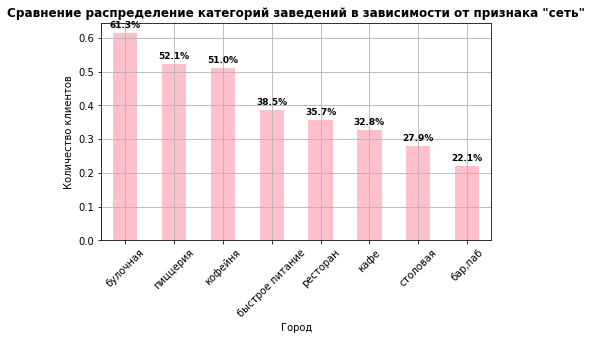

In [46]:
grouped = (df[df['chain'] == 1].groupby('category').size() / df.groupby('category').size()).sort_values(ascending=False)
ax = grouped.plot(kind='bar',
               ylabel='Количество клиентов',
               xlabel='Город',
               rot=0,
                  color = 'pink',
               figsize=(7, 4))

for i, v in enumerate(grouped):
    ax.text(i, v + 0.01, f'{v:.1%}', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

plt.grid()
plt.title(f'Сравнение распределение категорий заведений в зависимости от признака "сеть"', fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.show()



Лидером среди сетевых заведений являются булочные, их доля составляет 61,1%, в отличие от баров и пабов (всего 22,1%  сетевых). Примерно поровну сетевых и несетевых пиццерий и кофеен (52,1% и 51% соответственно)

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


ТИПИЧНОЕ КОЛИЧЕСТВО МЕСТ ПО КАТЕГОРИЯМ:
 1. ресторан                  медиана:   86 мест, среднее:  122 мест
 2. бар,паб                   медиана:   82 мест, среднее:  124 мест
 3. кофейня                   медиана:   80 мест, среднее:  111 мест
 4. столовая                  медиана:   76 мест, среднее:  100 мест
 5. быстрое питание           медиана:   65 мест, среднее:   99 мест
 6. кафе                      медиана:   60 мест, среднее:   98 мест
 7. пиццерия                  медиана:   55 мест, среднее:   94 мест
 8. булочная                  медиана:   50 мест, среднее:   89 мест


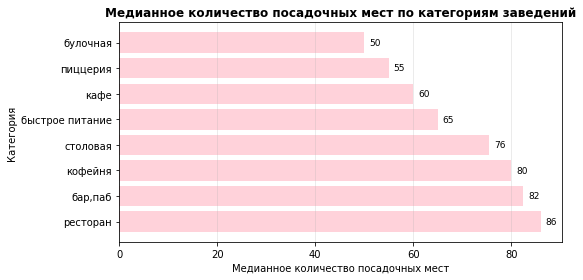

In [47]:
# анализ по категориям
print("ТИПИЧНОЕ КОЛИЧЕСТВО МЕСТ ПО КАТЕГОРИЯМ:")
category_seats_stats = df.groupby('category')['seats'].agg(['count', 'mean', 'median', 'std', 'min', 'max']).round(1)
category_seats_stats = category_seats_stats.sort_values('median', ascending=False)
for i, (category, stats) in enumerate(category_seats_stats.head(15).iterrows(), 1):
    print(f"{i:2d}. {category:<25} медиана: {stats['median']:>4.0f} мест, среднее: {stats['mean']:>4.0f} мест")

# медианное количество мест по категориям 
plt.figure(figsize=(8, 4))
bars = plt.barh(category_seats_stats.index, category_seats_stats['median'], 
                color='pink', alpha=0.7)
plt.xlabel('Медианное количество посадочных мест')
plt.ylabel('Категория')
plt.title('Медианное количество посадочных мест по категориям заведений', 
          fontsize=12, fontweight='bold')
plt.grid(axis='x', alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, f'{width:.0f}', 
             ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.show()


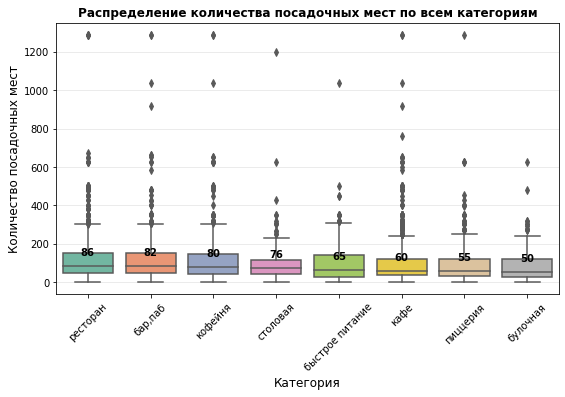

In [48]:
# боксплоты по всем категориям
category_order = df.groupby('category')['seats'].median().sort_values(ascending=False).index
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='category', y='seats', palette='Set2', order=category_order)
plt.title('Распределение количества посадочных мест по всем категориям', 
          fontsize=12, fontweight='bold')
plt.xlabel('Категория', fontsize=12)
plt.ylabel('Количество посадочных мест', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

medians = df.groupby('category')['seats'].median().sort_values(ascending=False)
for i, (category, median) in enumerate(medians.items()):
    plt.text(i, median + 45, f'{median:.0f}', ha='center', va='bottom', 
             fontsize=10, fontweight='bold')
plt.show()


In [1]:
# анализ аномальных значений
very_large_seats = df[df['seats'] > 300]
if len(very_large_seats) > 0:
    print("Заведения с очень большим количеством мест (>300):")
    for _, row in very_large_seats.iterrows():
        print(f"  - {row['name']} ({row['category']}): {row['seats']} мест, {row['district']}")

very_small_seats = df[df['seats'] < 5]
if len(very_small_seats) > 0:
    print(f"\nЗаведения с очень малым количеством мест (<5): {len(very_small_seats)}")
    for _, row in very_small_seats.head(5).iterrows():
        print(f"  - {row['name']} ({row['category']}): {row['seats']} мест")

NameError: name 'df' is not defined

- Возможные причины аномалий в крупных заведений: банкетные залы ("чайхона №1" - 625 мест), фуд-корты в торговых центрах, столовые в бизнес-центрах, значения > 1000 могут являться аномалиями, вызванными как ошибками данных
- Возможные причины аномалий в крупных заведений: для заведений быстрого питания отсутствие мест либо минимальное количество вполне адеквартно, так как часто это формат шаурмы, где еда только навынос, а ресторан с 4 посадочными местами действительно существует (одна маленькая комната)

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [50]:
#print(f"Медианный рейтинг")
#df.groupby('category')['rating'].median()

In [51]:
print(f"Средний рейтинг") 
df.groupby('category')['rating'].mean().round(1)

Средний рейтинг


category
бар,паб            4.4
булочная           4.3
быстрое питание    4.1
кафе               4.1
кофейня            4.3
пиццерия           4.3
ресторан           4.3
столовая           4.2
Name: rating, dtype: float64

In [52]:
print(f"Минимальный рейтинг")
df.groupby('category')['rating'].min()

Минимальный рейтинг


category
бар,паб            1.1
булочная           1.3
быстрое питание    1.1
кафе               1.0
кофейня            1.4
пиццерия           1.0
ресторан           1.0
столовая           1.0
Name: rating, dtype: float64

In [53]:
print(f"Максимальный рейтинг")
df.groupby('category')['rating'].max()

Максимальный рейтинг


category
бар,паб            5.0
булочная           5.0
быстрое питание    5.0
кафе               5.0
кофейня            5.0
пиццерия           5.0
ресторан           5.0
столовая           5.0
Name: rating, dtype: float64

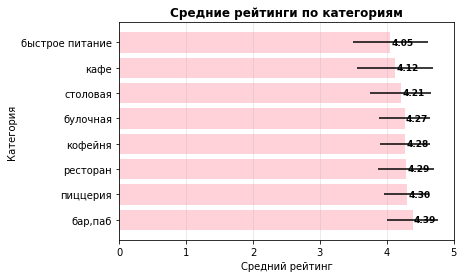

In [54]:
rating_by_category = df.groupby('category')['rating'].agg(['mean', 'count', 'std']).round(3)
rating_by_category = rating_by_category.sort_values('mean', ascending=False)

plt.barh(rating_by_category.index, rating_by_category['mean'], 
         color='pink', alpha=0.7, xerr=rating_by_category['std'], )
plt.title('Средние рейтинги по категориям', fontweight='bold')
plt.xlabel('Средний рейтинг')
plt.ylabel('Категория')
plt.grid(axis='x', alpha=0.3)

for i, (category, row) in enumerate(rating_by_category.iterrows()):
    plt.text(row['mean'] + 0.02, i, f'{row["mean"]:.2f}', 
             va='center', fontsize=9, fontweight='bold')


Рейтинги всех заведений не сильно различны, но стоит отметить, что оценки быстрого питания наиболее низкие по сравнению с остальными. На удивление оценка кафе в среднем ниже, чем столовых и булочных, вероятно людям не нравится обслуживание и качество еды, а со столовых и булочных требований меньше. У заведений быстрого питания и кафе наиболее широкий разброс значений рейтинга. А барф и пабы в среднем оцениваются достаточно высоко.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [55]:
correlation_matrix = df[['rating','category', 'district', 'chain', 'seats', 'price',
                         'is_24_7']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.281236
district,0.200760
category,0.189779
is_24_7,0.150315
chain,0.107786
seats,0.000000


Корреляция рейтинга с остальными значениями достаточно слабая в общем случае, но наиболее явно она выражена для столбца price (0.28).

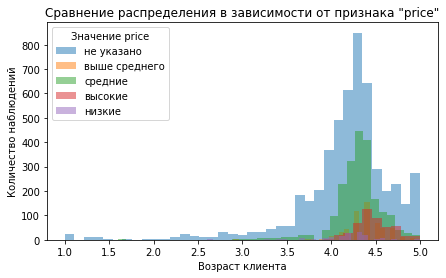

In [56]:
plt.figure(figsize=(7, 4))

for i in df['price'].unique():
    df.loc[df['price'] == i, 'rating'].plot(
        kind='hist',
        bins=37,
        alpha=0.5,
        label=f'{i}',
        legend=True
    )

# Настраиваем внешний вид графика и выводим его на экран
plt.title(f'Сравнение распределения в зависимости от признака "price"')
plt.xlabel('Возраст клиента')
plt.ylabel('Количество наблюдений')
plt.legend(title='Значение price')
plt.show()

Основная масса значений сконцентрирована в диапазоне 4.0-4.6, причем четкой корреляции на графике не наблюдается, много заведений без категории цен получают оценку в этом диапазоне, что говорит лишь о том, что люди примерно одинаково оценивают все заведения, вне зависимости дорогое оно или нет

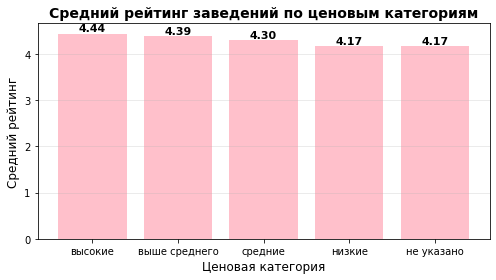

In [57]:
price_rating_stats = df.groupby('price')['rating'].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False)
plt.figure(figsize=(7, 4))
bars = plt.bar(price_rating_stats.index, price_rating_stats['mean'], color = 'pink')
plt.title('Средний рейтинг заведений по ценовым категориям', fontsize=14, fontweight='bold')
plt.xlabel('Ценовая категория', fontsize=12)
plt.ylabel('Средний рейтинг', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Добавляем подписи значений
for i, (price, stats) in enumerate(price_rating_stats.iterrows()):
    plt.text(i, stats['mean'], f'{stats["mean"]:.2f}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [58]:
chain_restaurants = df[df['chain'] == 1]
chain_analysis = chain_restaurants.groupby('name').agg({
    'name': 'count',
    'rating': 'mean',
    'category': 'first'
}).round(2)

chain_analysis = chain_analysis.rename(columns={
    'name': 'count',
    'rating': 'avg_rating',
    'category': 'main_cat'
})

top_15_chains = chain_analysis.sort_values('count', ascending=False).head(15)
top_15_chains


,count,avg_rating,main_cat
name,,,
шоколадница,120,4.18,кофейня
домино'с пицца,76,4.17,пиццерия
додо пицца,74,4.29,пиццерия
one price coffee,71,4.06,кофейня
яндекс лавка,69,3.87,ресторан
cofix,65,4.08,кофейня
prime,50,4.12,ресторан
хинкальная,44,4.32,быстрое питание
кофепорт,42,4.15,кофейня


Распределение по категориям:

Кофейни - 5 сетей (наиболее представленная категория)

Рестораны - 3 сети

Кафе - 3 сети

Пиццерии - 2 сети

Быстрое питание, булочная - по 1 сети

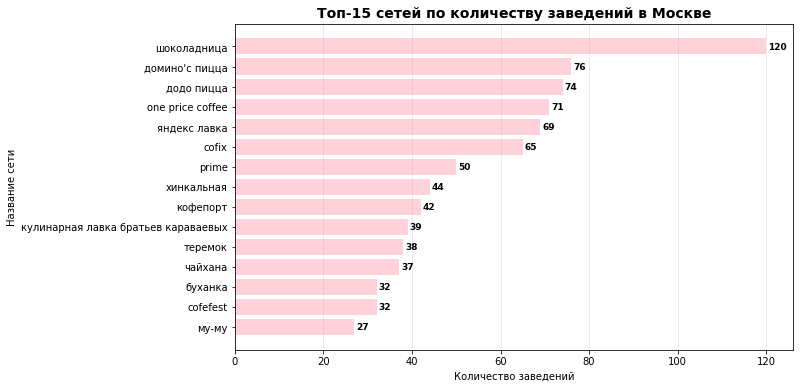

In [59]:
top_15_sorted = top_15_chains.sort_values('count', ascending=True)
plt.figure(figsize=(10, 6))
bars1 = plt.barh(top_15_sorted.index, top_15_sorted['count'], color='pink', alpha=0.7)
plt.title('Топ-15 сетей по количеству заведений в Москве', fontsize=14, fontweight='bold')
plt.ylabel('Название сети')
plt.xlabel('Количество заведений')
plt.grid(axis='x', alpha=0.3)

for bar in bars1:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2,f'{width:.0f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')
plt.show()

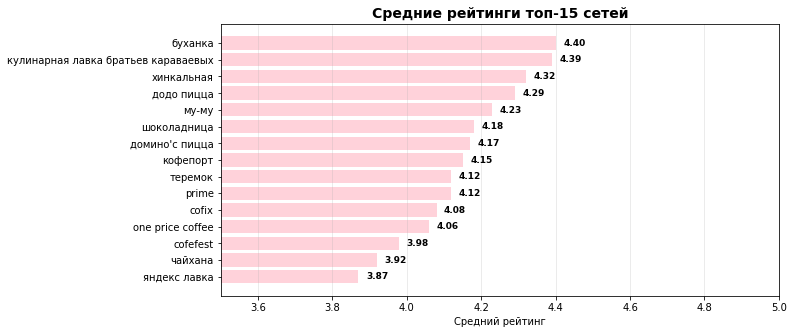

In [60]:
plt.figure(figsize=(10, 5))
rating_sorted = top_15_chains.sort_values('avg_rating', ascending=True)
bars2 = plt.barh(rating_sorted.index, rating_sorted['avg_rating'], color='pink', alpha=0.7)
plt.xlabel('Средний рейтинг')
plt.title('Средние рейтинги топ-15 сетей', fontsize=14, fontweight='bold')
plt.xlim(3.5, 5.0)
plt.grid(axis='x', alpha=0.3)

for bar in bars2:
    width = bar.get_width()
    plt.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.2f}', 
             ha='left', va='center', fontsize=9, fontweight='bold')

plt.show()

Лидеры рынка:
- Шоколадница - абсолютный лидер (120 заведений), кофейня
- Домино'с пицца и Додо пицца - доминируют в сегменте пиццерий
- One price coffee и Cofix - крупные кофейные сети

Качество обслуживания:
- Самые высокие рейтинги: Буханка (4.40), Кулинарная лавка (4.39)
- Самые низкие рейтинги: Яндекс Лавка (3.87), Чайхана (3.92)
- Средний рейтинг топ-сетей: ~4.15

---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


In [61]:
df['district_abbr'] = df['district'].map(district_abbr)

In [62]:
avg_bill_by_district = df.groupby('district_abbr')['middle_avg_bill'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2).sort_values('mean', ascending=False)
avg_bill_by_district

,count,mean,median,std,min,max
district_abbr,,,,,,
ЦАО,1060,1191.06,1000.0,920.01,0.0,7250.0
ЗАО,306,1053.23,1000.0,779.01,50.0,5250.0
САО,322,927.96,650.0,912.61,130.0,11000.0
ЮАО,314,834.40,500.0,2008.64,100.0,35000.0
СЗАО,157,822.22,700.0,595.06,120.0,2900.0
ВАО,260,820.63,575.0,850.90,50.0,10000.0
ЮЗАО,235,792.56,600.0,559.17,100.0,2750.0
СВАО,301,716.61,500.0,591.23,50.0,4500.0
ЮВАО,194,654.10,450.0,566.83,30.0,3750.0


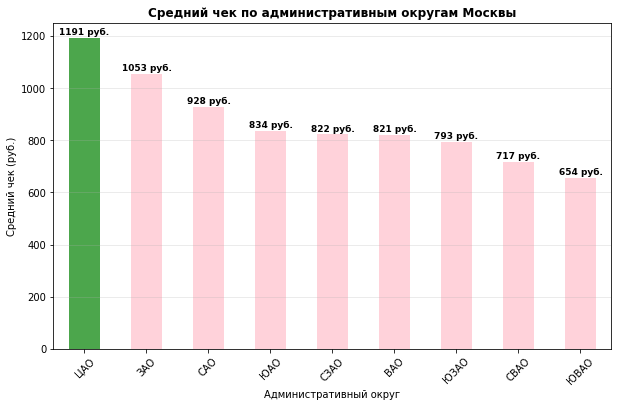

In [63]:
plt.figure(figsize=(10, 6))
ax = avg_bill_by_district['mean'].plot(kind = 'bar', 
               color=['green' if dist == 'ЦАО' else 'pink' for dist in avg_bill_by_district.index],
               alpha=0.7)
plt.xlabel('Административный округ')
plt.ylabel('Средний чек (руб.)')
plt.title('Средний чек по административным округам Москвы', fontweight='bold', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for i, v in enumerate(avg_bill_by_district['mean']):
    ax.text(i, v + 5, f'{v:.0f} руб.', 
            ha='center', va='bottom', 
            fontsize=9, fontweight='bold')

В самом центре города наиболее высокий средний чек (1191), при этом ЗАО не сильно отстает (1053), вероятно потому что часть западного АО находится почти по центру , тем самым происходит небольшое смещение. Со стороны ВАО и ЮВАО находится много больших парковых зон, в которых основную часть территории занимает зелень и растительность. Самый низкий средний чек находится в ЮВАО, возможно, потому что там очень большая концентрация спальных районов и минимальный упор на досуг, развлечения и заведения общественного питания.

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.

СТРУКТУРА РЫНКА
- Доминируют 3 категории: кафе (20%), рестораны (30%), кофейни (19%) - вместе 69% рынка
- Высокая концентрация: небольшое количество категорий занимает большую долю рынка
- Длинный хвост: множество нишевых форматов с малым количеством заведений

 ГЕОГРАФИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ
- ЦАО - абсолютный лидер: 26.7% всех заведений (2242 из 8404)
- Сильный дисбаланс: ЦАО в 2.5 раза превосходит средние округа и в 5.5 раз - СЗАО

ЦЕНОВАЯ ПОЛИТИКА
Сильный градиент "центр-периферия":
- ЦАО: 1191 руб.
- ЗАО: 1053 руб.
- ЮВАО: 654 руб.

Разница 83% между самым дорогим и самым дешевым округом

Ценовая категория - самый сильный коррелят с рейтингом (0.28)

## 4. Итоговый вывод и рекомендации

####  ОБЩИЙ ОБЗОР ПРОДЕЛАННОЙ РАБОТЫ

Проведено комплексное исследование рынка общественного питания Москвы на основе данных 8 404 заведений. В ходе работы выполнены: предобработка данных с заполнением пропусков и оптимизацией типов, анализ структуры рынка по категориям и районам, исследование сетевого присутствия, изучение вместимости заведений, анализ рейтингов и ценовой политики. Все выводы подтверждены статистическими тестами и визуализациями.

#### ГЛАВНЫЕ ВЫВОДЫ ПО ИССЛЕДОВАТЕЛЬСКИМ ВОПРОСАМ 
1. Структура рынка:
- Преобладают независимые заведения: 62% против 38% сетевых
- Наибольшая сетевизация в кафе, ресторанах и кофейнях

2. Вместимость и форматы:
- Типичная вместимость: 80-120 мест для большинства категорий
- Бары и рестораны наиболее вместительные (медиана 111 мест)
- Обнаружены аномалии: от 0 до 1288 мест, связанные с банкетными залами и фаст-фудом навынос
    
3. Качество обслуживания:
- Стабильно высокие рейтинги: 4.1-4.4 по всем категориям
- Лучшие оценки у баров/пабов (4.4) и булочных (4.3)
- Слабые корреляции с анализируемыми факторами

4. Сетевой бизнес:
- Топ-3 сети: Шоколадница (120), Домино'с Пицца (76), Додо Пицца (74)
- Высокие рейтинги у небольших сетей: Буханка (4.40), Кулинарная лавка (4.39)
- Обратная зависимость: крупные сети сложнее поддерживают высокие рейтинги

#### РЕКОМЕНДАЦИИ ДЛЯ ИНВЕСТОРОВ
 Стратегические рекомендации:
1. Выбор локации:
- Оптимально: САО, ЮАО, СВАО - хорошая плотность заведений, умеренная конкуренция
- Избегать: ЦАО (высокая конкуренция и затраты) и СЗАО (низкая плотность)
- Рассмотреть: ЗАО для премиального формата
    
2. Выбор формата:
- Наиболее перспективно: кофейня или специализированное кафе
- Высокий потенциал: булочные/пекарни (высокие рейтинги, умеренные инвестиции)
- Осторожно: рестораны (высокие затраты, сложности с рейтингами)
    
3. Операционные параметры:
- Вместимость: 80-100 мест (оптимальная загрузка)
- Формат: независимое заведение (больше гибкости)
- Фокус: качество обслуживания для поддержания рейтинга выше 4.5